# Fine-tuning GPT-2 - detect Spam messages


### Load the SMS Spam dataset



In [12]:
from datasets import load_dataset

sms_spam_dataset = load_dataset('ucirvine/sms_spam')
print(sms_spam_dataset)

DatasetDict({
    train: Dataset({
        features: ['sms', 'label'],
        num_rows: 5574
    })
})


In [13]:
sms_spam_dataset['train'][0]

{'sms': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n',
 'label': 0}

### Train-Test Split

In [14]:
train_test_split = 0.9

shuffled_dataset = sms_spam_dataset['train'].shuffle()
train_len = int(len(shuffled_dataset) * train_test_split)

training_data = shuffled_dataset[:train_len]
validation_data = shuffled_dataset[train_len:]

In [15]:
def get_spam_non_spam_count(data):
    spam = 0
    for label in data['label']:
        if label == 1:
            spam += 1
    print(f'Spam: {spam}, Non Spam: {len(data['label']) - spam}')
    print(f'Spam: {(spam/len(data['label']))*100}%')

print(f'Training data size: {len(training_data['sms'])}')
get_spam_non_spam_count(training_data)
print(f'Validation data size: {len(validation_data['sms'])}')
get_spam_non_spam_count(validation_data)

Training data size: 5016
Spam: 671, Non Spam: 4345
Spam: 13.37719298245614%
Validation data size: 558
Spam: 76, Non Spam: 482
Spam: 13.620071684587815%


## Tokenize the dataset

In [16]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

In [17]:
def tokenize_dataset(dataset):
    tokenized_dataset = []

    for message, label in zip(dataset['sms'], dataset['label']):
        encoded_ids = tokenizer.encode(message)
        tokenized_dataset.append((encoded_ids, label))
    
    return tokenized_dataset

In [19]:
tokenized_training_dataset = tokenize_dataset(training_data)
tokenized_validation_dataset = tokenize_dataset(validation_data)

print(tokenized_training_dataset[0])
print(tokenizer.decode(tokenized_training_dataset[0][0]))

([41, 385, 1625, 736, 1216, 9965, 266, 361, 616, 264, 271, 691, 13, 471, 443, 71, 30, 198], 0)
Jus came back fr lunch wif my sis only. U leh?



## Load GPT-2 Model

In [21]:
from transformers import GPT2Model

model = GPT2Model.from_pretrained('gpt2')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [22]:
model

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
)

We can see the final (Layer-Norm) layer has an out dimension of **768**. We need to add an additional custom layer after the LayerNorm layer which will classify the input text as **spam (0)** or **not-spam (1)**.

Before that let's generate some content from the GPT-2 model.

In [23]:
from transformers import pipeline
generator = pipeline('text-generation', model='gpt2')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [28]:
generator("kill him", max_length=30, num_return_sequences=1)

[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'kill him to death.\n\n"He\'s the villain," explained Afton. "He\'s a bad guy. He\'s a villainous man."\n\nHe added that Bambur would never be able to return to the world where he was born.\n\n"It\'s too dangerous," he added. "I don\'t want him there, I want him there and I want to keep him there."\n\nBambur\'s death was the second death of Bambur\'s family since he was found dead in 2003. His father, who had been a member of the New Zealand Police Service, had been charged with manslaughter for the incident.\n\nAccording to police, Bambur, who was born in New Zealand but moved to Australia a short time later, did not have a criminal record.\n\nBambur was found in a car at his home in the city of New Plymouth in August 2015, and was taken to a hospital where he died.\n\nThe coroner confirmed that Bambur had suffered a fractured skull and fractured ribs, a broken left shoulder and an aorta. He had been taken to a hospital in New Plymouth where he died.\n\nThe coroner

In [29]:
from torch import nn
import torch


class GptForSentimentAnalysis(nn.Module):
    def __init__(self):
        super(GptForSentimentAnalysis, self).__init__()

        self.gpt2 = GPT2Model.from_pretrained('gpt2') # out dimension = 768
        self.out_layer = nn.Linear(768, 2) # out dimension = 2
    
    def forward(self, input_ids):
        outputs = self.gpt2.forward(input_ids=input_ids)
        hidden_states = outputs.last_hidden_state

        # --- THE CRITICAL GPT-2 TRICK ---
        # Because GPT-2 is a causal (left-to-right) model, the meaningful context 
        # for the whole sentence accumulates at the VERY LAST token. 
        # So, we usually extract just the last token's hidden state to pass to our new layer.
        
        # Grab the last token's representation for each sequence in the batch
        # (Assuming you are padding appropriately)
        last_token_states = hidden_states[:, -1, :] # B, 1, 768

        final_output = self.out_layer(last_token_states) # B, 1, 2

        return final_output
    
    def predict(self, sms: str):
        encoded_ids = tokenizer.encode(sms)
        encoded_ids = torch.tensor([encoded_ids])

        logits = self.forward(encoded_ids)
        predicted_label = torch.argmax(logits, dim=-1)

        verdict = "Not Spam" if predicted_label == 0 else "Spam"

        return verdict

In [30]:
gpt2_sentiment_model = GptForSentimentAnalysis()
gpt2_sentiment_model

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GptForSentimentAnalysis(
  (gpt2): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (out_layer): Linear(in_features=768, out_features=2, bias=True)
)

In [31]:
f'{(sum(parameter.numel() for parameter in gpt2_sentiment_model.parameters()) / 1e6):.2f} million parameters'

'124.44 million parameters'

## Fine-tune

In [34]:
# Feeze the entire model
for parameter in gpt2_sentiment_model.parameters():
    parameter.requires_grad = False

# Making the last attention block trainable
for parameter in gpt2_sentiment_model.gpt2.h[-1].parameters():
    parameter.requires_grad = True

# Making the last output layer trainable as well
for parameter in gpt2_sentiment_model.out_layer.parameters():
    parameter.requires_grad = True

In [36]:
sum(
    parameter.numel() for parameter in gpt2_sentiment_model.out_layer.parameters()
) + sum(parameter.numel() for parameter in gpt2_sentiment_model.gpt2.h[-1].parameters())

7089410

In [37]:
def get_mean(losses):
    sum = 0.0
    for loss in losses:
        sum += loss.item()
    return sum / len(losses)

In [39]:
from torch.nn.utils.rnn import pad_sequence

gpt2_sentiment_model.train()

epochs = 2
batch_size = 8
eval_intervals = batch_size * 50 # We log the training loss after processing 50 batches
losses = []
overall_losses = []

optimizer = torch.optim.AdamW(gpt2_sentiment_model.parameters(), lr=5e-5, weight_decay=0.1)

for epoch in range(epochs):
    Xb = []
    Yb = []
    print(f'Epoch: {epoch+1}')

    for i, row in enumerate(tokenized_training_dataset):
        encoded_msg = row[0]
        label = row[1]
        Xb.append(torch.tensor(encoded_msg))
        Yb.append(torch.tensor(label))

        if (len(Xb) % batch_size) == 0:
            padded_batch = pad_sequence(Xb, batch_first=True, padding_value=0)
            logits = gpt2_sentiment_model(padded_batch)
            loss = torch.nn.functional.cross_entropy(logits, torch.tensor(Yb))
            losses.append(loss)
            overall_losses.append(loss)
            loss.backward()
            optimizer.step()
            Xb = []
            Yb = []

            if (i+1)%eval_intervals == 0:
                print(f'Interval: {i+1}, Loss: {get_mean(losses)}')
                losses = []
    
    if len(Xb) > 0:
        padded_batch = pad_sequence(Xb, batch_first=True, padding_value=0)
        logits = gpt2_sentiment_model(padded_batch)
        loss = torch.nn.functional.cross_entropy(logits, torch.tensor(Yb))
        losses.append(loss)
        overall_losses.append(loss)
        loss.backward()
        optimizer.step()

Epoch: 1
Interval: 400, Loss: 0.5274094069795683
Interval: 800, Loss: 0.35100493867881594
Interval: 1200, Loss: 0.4056747117638588
Interval: 1600, Loss: 0.2526563310809433
Interval: 2000, Loss: 0.22109518164768815
Interval: 2400, Loss: 0.17257468484342098
Interval: 2800, Loss: 0.10786778471432626
Interval: 3200, Loss: 0.09058487300077105
Interval: 3600, Loss: 0.06587827471717901
Interval: 4000, Loss: 0.11797854926742729
Interval: 4400, Loss: 0.045594078390931825
Interval: 4800, Loss: 0.08041547075132258
Epoch: 2
Interval: 400, Loss: 0.10366736963246163
Interval: 800, Loss: 0.07099443786079064
Interval: 1200, Loss: 0.07684953331947326
Interval: 1600, Loss: 0.13164418257772922
Interval: 2000, Loss: 0.0736929101566784
Interval: 2400, Loss: 0.1255084725038614
Interval: 2800, Loss: 0.09925138351729401
Interval: 3200, Loss: 0.038159624113704924
Interval: 3600, Loss: 0.07140012526868304
Interval: 4000, Loss: 0.085351976776019
Interval: 4400, Loss: 0.0087044729101126
Interval: 4800, Loss: 0.04

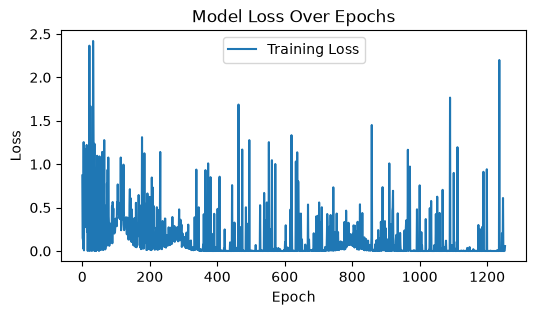

In [40]:
import matplotlib.pyplot as plt

def plot_loss_curve(losses):
    loss_list = [loss.item() for loss in losses]

    # Plot the loss curve
    plt.figure(figsize=(6, 3)) # Optional: adjust figure size
    plt.plot(loss_list, label='Training Loss')

    # Add titles and labels
    plt.title('Model Loss Over Epochs')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend() # Show the legend

    # Display the plot
    plt.show()

plot_loss_curve(overall_losses)

Let's also write a method to get the model's accuracy on the entire dataset.

In [41]:
def get_dataset_accuracy(tokenized_dataset, log_interval):
    encoded_messages = [row[0] for row in tokenized_dataset]
    labels = [row[1] for row in tokenized_dataset]
    processed = 0
    correct_predictions = 0

    for encoded_message, label in zip(encoded_messages, labels):
        with torch.no_grad():
            encoded_message = torch.tensor(encoded_message).view(1,len(encoded_message))
            logits = gpt2_sentiment_model(torch.tensor(encoded_message))
        predicted_label = torch.argmax(logits, dim=-1)
        
        if predicted_label == label:
            correct_predictions += 1
        
        if processed%log_interval == 0:
            print(f'Processed: {processed}')
        processed += 1

    print(f'{correct_predictions} / {len(encoded_messages)}')
    accuracy = (correct_predictions/len(encoded_messages)) * 100.0
    print(f'Accuracy: {accuracy}')

    return accuracy

In [42]:
train_accuracy = get_dataset_accuracy(tokenized_training_dataset, log_interval=500)
print(f'Training dataset accuracy: {train_accuracy}')

C:\Users\USER\AppData\Local\Temp\ipykernel_32116\1134791077.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits = gpt2_sentiment_model(torch.tensor(encoded_message))


Processed: 0
Processed: 500
Processed: 1000
Processed: 1500
Processed: 2000
Processed: 2500
Processed: 3000
Processed: 3500
Processed: 4000
Processed: 4500
Processed: 5000
4959 / 5016
Accuracy: 98.86363636363636
Training dataset accuracy: 98.86363636363636


In [43]:
validation_accuracy = get_dataset_accuracy(tokenized_validation_dataset, log_interval=100)
print(f'Validation dataset accuracy: {validation_accuracy}')

C:\Users\USER\AppData\Local\Temp\ipykernel_32116\1134791077.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits = gpt2_sentiment_model(torch.tensor(encoded_message))


Processed: 0
Processed: 100
Processed: 200
Processed: 300
Processed: 400
Processed: 500
545 / 558
Accuracy: 97.67025089605734
Validation dataset accuracy: 97.67025089605734


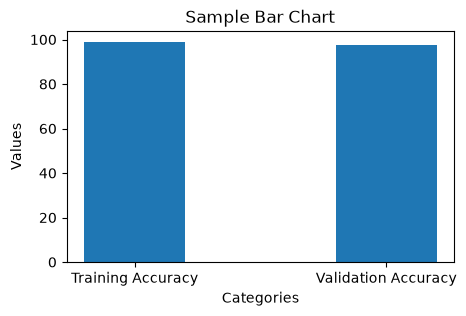

In [44]:
import numpy as np

def plot_bar_chart(training_accuracy, validation_accuracy):
    # Data for the bar chart
    categories = np.array(["Training Accuracy", "Validation Accuracy"])
    values = np.array([training_accuracy, validation_accuracy])

    # Create the bar chart
    plt.figure(figsize=(5, 3))
    plt.bar(categories, values, width=0.4)

    # Add labels and a title
    plt.xlabel("Categories")
    plt.ylabel("Values")
    plt.title("Sample Bar Chart")

    # Display the chart
    plt.show()

plot_bar_chart(train_accuracy, validation_accuracy)

In [45]:
messages = [
    'Last a chance to win 1 Lakh, call at 5676 now!',
    'How are you doing?',
    'Get home loan at low rates now, click to this link http://win/ to know more',
    'Reaching your location in 5 minutes'
]

for message in messages:
    prediction = gpt2_sentiment_model.predict(message)
    print(f'{message} -> {prediction}')

Last a chance to win 1 Lakh, call at 5676 now! -> Spam
How are you doing? -> Not Spam
Get home loan at low rates now, click to this link http://win/ to know more -> Spam
Reaching your location in 5 minutes -> Not Spam
